In [ ]:
!pip install optuna
!pip install captum

# Imports and Device

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Data Loading and Exploration

In [ ]:
df = pd.read_csv('train.csv', index_col= 'ID')
df.head()

,05/04/2010,06/04/2010,07/04/2010,08/04/2010,09/04/2010,12/04/2010,13/04/2010,14/04/2010,15/04/2010,16/04/2010,...,18/03/2022,21/03/2022,22/03/2022,23/03/2022,24/03/2022,25/03/2022,28/03/2022,29/03/2022,30/03/2022,31/03/2022
ID,,,,,,,,,,,,,,,,,,,,,
company_0,1.30,0.19,0.46,-0.23,1.20,-0.26,-0.34,1.64,1.21,-0.85,...,-0.36,0.05,0.30,-3.10,0.04,0.86,0.31,0.95,0.68,-0.52
company_1,-0.83,0.62,-2.74,6.33,1.32,4.52,0.05,3.94,5.01,-3.11,...,2.20,-3.67,3.20,-1.61,2.92,0.93,1.55,3.96,0.41,1.08
company_2,-0.02,0.13,-0.70,0.23,1.50,-0.23,1.35,2.26,0.37,-3.49,...,-0.16,-0.74,2.52,-2.06,1.57,0.10,0.90,3.05,-1.24,-1.26
company_3,-1.10,-0.73,-2.98,1.98,3.00,1.01,3.60,4.30,1.05,-7.66,...,2.47,-2.41,1.10,-4.08,2.09,2.02,2.74,2.33,0.80,-0.91
company_4,2.23,-1.45,-1.74,-1.13,0.80,1.29,0.62,3.06,-0.73,-0.22,...,1.28,-1.96,0.19,-2.28,-1.13,-1.53,-0.64,2.32,-1.64,-4.58


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 442 entries, company_0 to company_441
Columns: 3021 entries, 05/04/2010 to 31/03/2022
dtypes: float64(3021)
memory usage: 10.2+ MB


In [ ]:
df.shape

(442, 3021)

In [ ]:
print("Shape:", df.shape)
print("Date range:", df.columns[0], "to", df.columns[-1])
print("Number of companies:", df.shape[0])
print("Number of trading days:", df.shape[1])
print("Sum of missing values:", df.isnull().sum().sum())

Shape: (442, 3021)
Date range: 05/04/2010 to 31/03/2022
Number of companies: 442
Number of trading days: 3021
Sum of missing values: 0


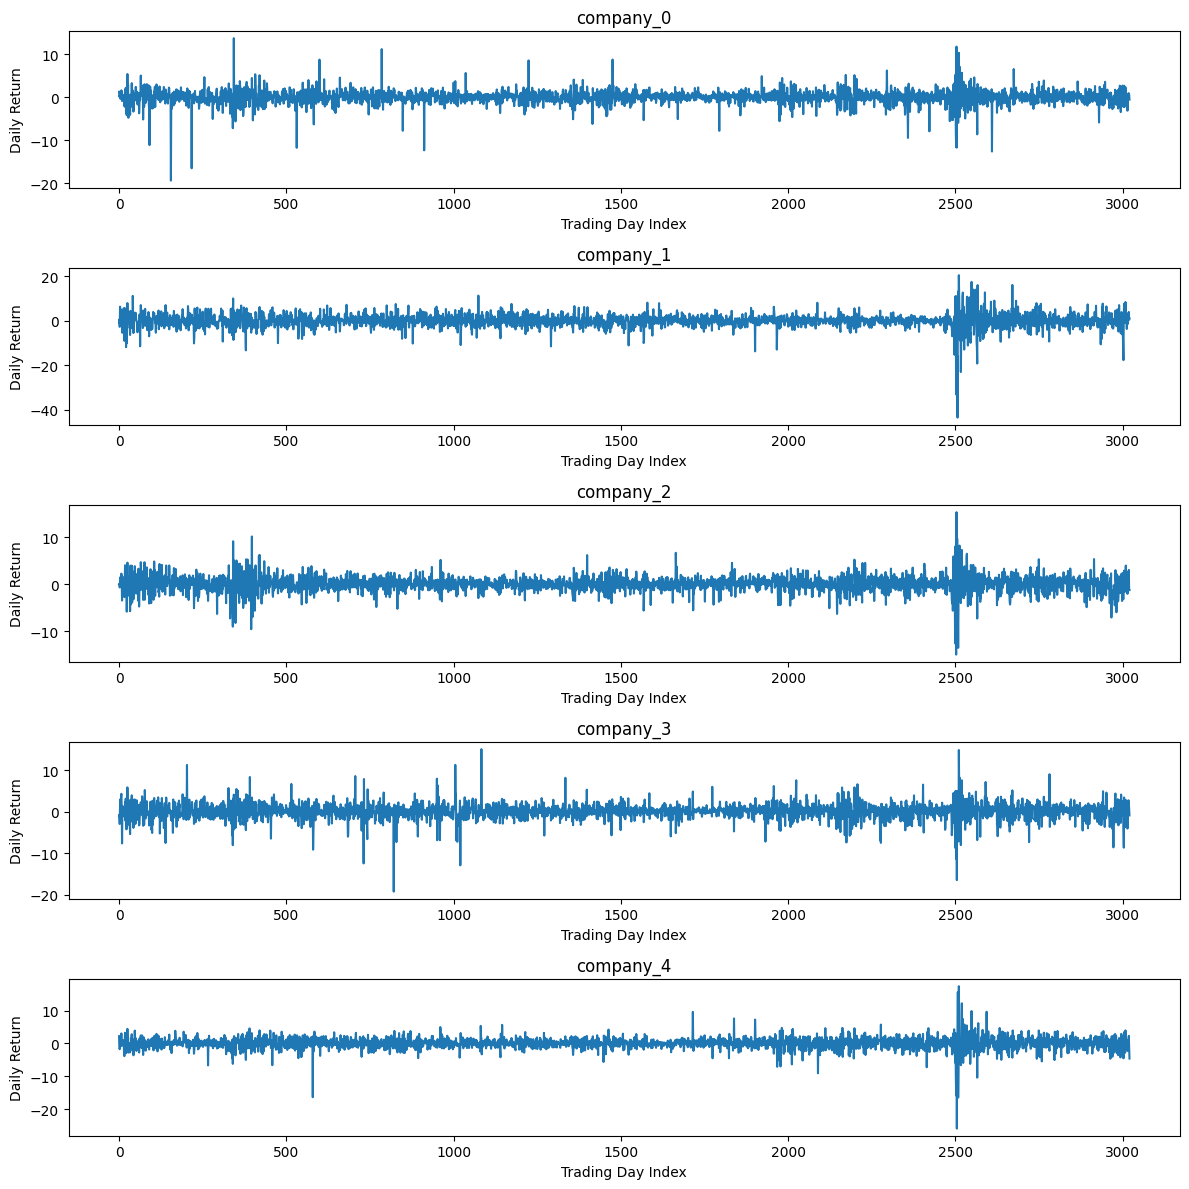

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12,12)) # axes = [ax0, ax1, ax2, ax3, ax4]

for i, ax in enumerate(axes):
    ax.plot(df.iloc[i].values) # df.iloc[0] = row 0 = company_0
                              # .values = [1.3, 0.19, 0.46, ...] (3021 numbers)
                              # draws those numbers as a line on ax0
    ax.set_title(f'{df.index[i]}')
    ax.set_xlabel('Trading Day Index')
    ax.set_ylabel('Daily Return')

plt.tight_layout()
plt.show()

## Observations from Data Exploration

1. **All companies show similar patterns** — daily returns fluctuate around 0.

2. **Different volatility levels** — company_1 ranges between -40 and +20, while company_0 and company_2 ranges within -20 to +10. This shows that companies have different scales or spreads, which is why normalisation is necessary.

3. **Large spikes around index 2500** — visible across all companies.

4. **No obvious trend** — the data doesn't consistently go up or down over time.

5. **Justification for StandardScaler** — because companies have different volatility levels, we normalise each company independently so the LSTM treats all companies equally regardless of their scale.

# Data Preprocessing

### Normalisation
1) From the graphs we can see there are some spikes. They are the outliers.
2) To handle the outliers **'StandardScaler'** is used
3) It keeps the mean 0 and std 1 for each company

In [ ]:
from sklearn.preprocessing import StandardScaler

# Convert Dataframe to numpy array
data = df.values

# Normalise
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.T).T  # transpose and scale per company (transpose because it scales column by column)

print("Original data shape:", data.shape)
print("Scaled data shape:", data_scaled.shape)
print("\nMean after scaling:", data_scaled[0].mean().round(4))
print("Std after scaling:", data_scaled[0].std().round(4))

Original data shape: (442, 3021)
Scaled data shape: (442, 3021)

Mean after scaling: -0.0
Std after scaling: 1.0


### lookback window



-> The create_sequences function slides a window of
fixed size across each company's time series to
create training examples.

-> A default lookback of 20 days is used here for
initial exploration.

In [ ]:
def create_sequences(data, lookback):
  """
  For each company, slide a window of size `lookback`.

  Input:
  data = data_scaled (442, 3021)
  lookback = number of past days to look at to predict the next day

  output:
  x shape (company, number of sequence, lookback)
  y shape (company, target)

  """
  x = [] # input windows for all companies
  y = [] # target values of all companies

  # loop through each company
  for c in data:
    x_company, y_company = [], [] # temporary list to hold the values of the current company

    # slide window and target
    for i in range(len(c)-lookback): # len(c)=3021 , subtracting lookback because each window needs lookback days + 1 target day, and if we go further that will be going beyond the data. so index error will happen
       x_company.append(c[i:i+lookback]) # c = company0, c[0:20] -> 0-19
       y_company.append(c[i+lookback]) # target = 0+20 = 20

    x.append(x_company)
    y.append(y_company)

  return np.array(x), np.array(y)


lookback = 20
x,y = create_sequences(data_scaled,lookback)

print("x shape:", x.shape)
print(f"company:{x.shape[0]}, windows per company: {x.shape[1]}, {x.shape[2]} days in each windows(lookback)")
print("y shape:", y.shape)

x shape: (442, 3001, 20)
company:442, windows per company: 3001, 20 days in each windows(lookback)
y shape: (442, 3001)


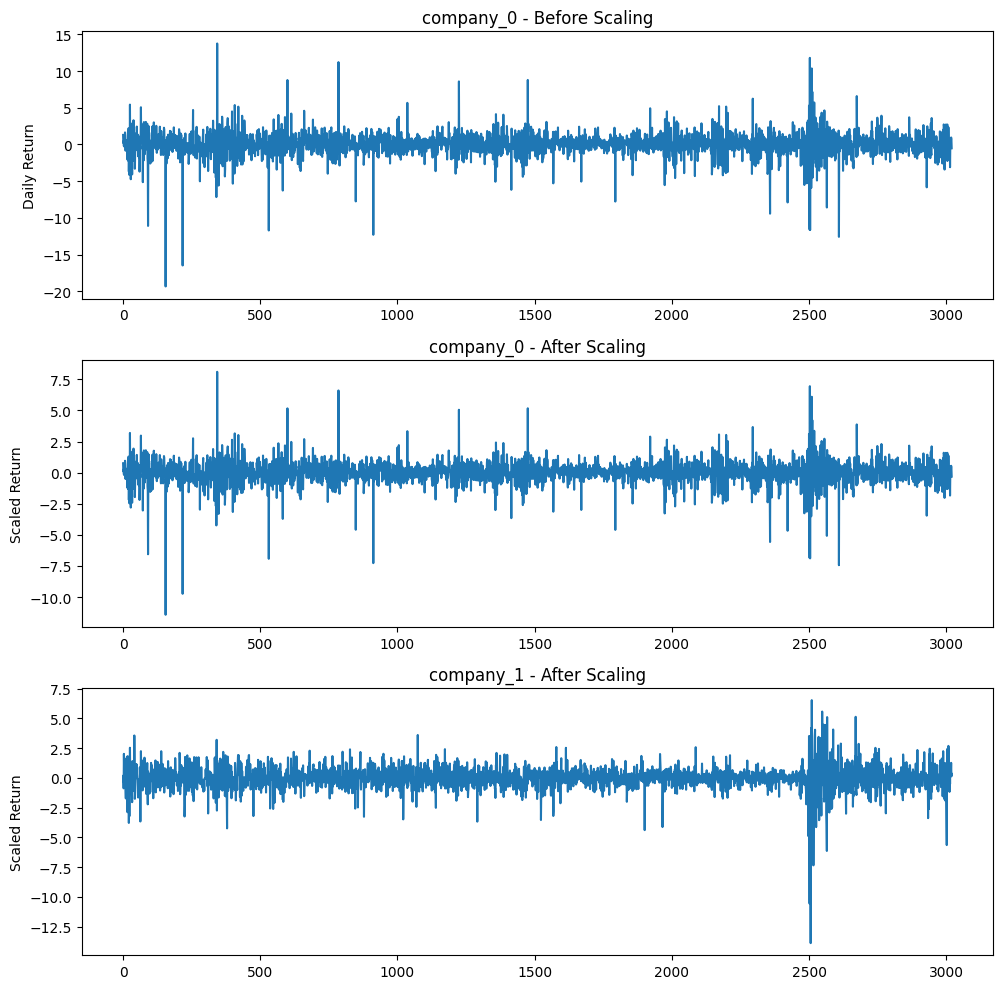

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Before scaling
axes[0].plot(data[0])
axes[0].set_title('company_0 - Before Scaling')
axes[0].set_ylabel('Daily Return')

# After scaling -> company_0
axes[1].plot(data_scaled[0])
axes[1].set_title('company_0 - After Scaling')
axes[1].set_ylabel('Scaled Return')

# After scaling -> company_1
axes[2].plot(data_scaled[1])
axes[2].set_title('company_1 - After Scaling')
axes[2].set_ylabel('Scaled Return')

plt.tight_layout()
plt.show()

## Scaling Graph Analysis

The three plots show:

1. **company_0 before scaling** return values ranging from -20 to +10.

2. **company_0 after scaling** same pattern but now standardised to mean=0 and std=1

3. **company_1 after scaling** a different company now on the same scale as company_0

Before scaling company_1 ranged from -40 to +20
while company_0 ranged from -20 to +10. After
scaling both companies are on a comparable range.
This ensures the LSTM treats all companies equally.

# Train and Validation Split

In [ ]:
# last 60 days as validation set
val_days = 60

# 3001-60 = 2941
# Split x and y for all companies
x_train = x[:, :-val_days, :]   # all companies, first 2941 windows, lookback
x_val   = x[:, -val_days:, :]   # all companies, last 60 windows, lookback
y_train = y[:, :-val_days]      # all companies, first 2941 targets
y_val   = y[:, -val_days:]      # all companies, last 60 targets

print("x_train shape:", x_train.shape)
print("x_val shape:",   x_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:",   y_val.shape)

x_train shape: (442, 2941, 20)
x_val shape: (442, 60, 20)
y_train shape: (442, 2941)
y_val shape: (442, 60)


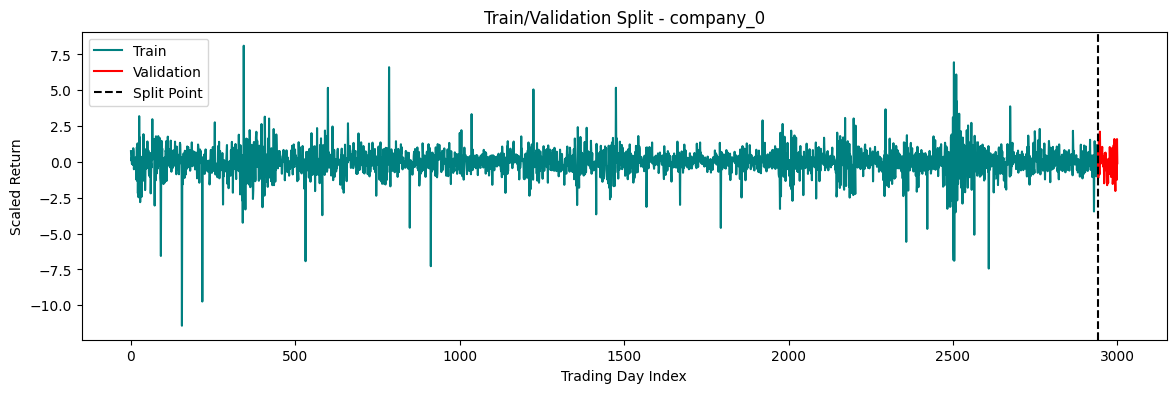

In [ ]:
plt.figure(figsize=(14, 4))

# plot training data
plt.plot(range(2941), data_scaled[0, :2941],
         label='Train', color='teal')

# plot validation data
plt.plot(range(2941, 3001), data_scaled[0, 2941:3001],
         label='Validation', color='red')

plt.axvline(x=2941, color='black', linestyle='--', label='Split Point')
plt.title('Train/Validation Split - company_0')
plt.xlabel('Trading Day Index')
plt.ylabel('Scaled Return')
plt.legend()
plt.show()

# Baseline Model

A baseline LSTM (Long Short-Term Memory) is used with fixed default hyperparameters to learn sequential patterns in stock returns.

Architecture:

-> LSTM layers: learn patterns

-> Dropout: prevent overfitting  

-> Linear layer: convert to a single prediction

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):

        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # LSTM layer with dropout
        self.lstm = nn.LSTM(input_size,
                            hidden_size,
                            num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)

        # Dropout layer after LSTM
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialise hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device) # short term memory
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device) # long term memory

        # Forward pass through LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Apply dropout to last timestep
        out = self.dropout(out[:, -1, :])

        # Final prediction
        out = self.fc(out)

        return out

# Initial parameters
model = LSTMModel(input_size=1,
                  hidden_size=64,
                  num_layers=2,
                  output_size=1,
                  dropout=0.2)
model = model.to(device)
print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# Training Function

In [ ]:
def train_model(model, x_train, y_train, x_val, y_val,
                epochs=50, batch_size=32, learning_rate=0.001):

    X_train_t = torch.FloatTensor(x_train.reshape(-1, x_train.shape[2], 1)).to(device)
    y_train_t = torch.FloatTensor(y_train.reshape(-1, 1)).to(device)
    X_val_t   = torch.FloatTensor(x_val.reshape(-1, x_val.shape[2], 1)).to(device)
    y_val_t   = torch.FloatTensor(y_val.reshape(-1, 1)).to(device)

    print("X_train_t shape:", X_train_t.shape)
    print("y_train_t shape:", y_train_t.shape)

    criterion = nn.MSELoss() # loss function
    optimiser = optim.Adam(model.parameters(), lr=learning_rate)

    # Scheduler -> reduces learning rate when validation loss stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser,
        mode='min',
        factor=0.5,
        patience=3, # atleast 3 epochs before reducing

    )

    train_losses  = []
    val_losses    = []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        epoch_loss  = 0
        num_batches = 0

        for i in range(0, X_train_t.size(0), batch_size):
            X_batch = X_train_t[i:i+batch_size] # i=0: ,  X_train_t[0:32]    -> first 32 sequences -> till last sequence
            y_batch = y_train_t[i:i+batch_size]

            optimiser.zero_grad() # clear out old gradients
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # caps gradient so that it doesn't explode
            optimiser.step()

            epoch_loss  += loss.item()
            num_batches += 1

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t)

        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())

        # Step scheduler
        scheduler.step(val_loss)

        # Save best model automatically
        if val_loss < best_val_loss:
            best_val_loss = val_loss.item()
            torch.save(model.state_dict(), 'best_model.pth')

        if epoch % 5 == 0: # printing every 5 epoch
            print(f"Epoch {epoch}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {val_loss.item():.4f} | "
                  f"LR: {optimiser.param_groups[0]['lr']:.6f}")

    # Load best model weights before returning
    model.load_state_dict(torch.load('best_model.pth'))
    print(f"\nBest Val Loss: {best_val_loss:.4f}")
    return train_losses, val_losses

## Training the Baseline Model

-> The baseline model is trained for 10 epochs with
default hyperparameters for a reference
performance score.

-> later this score will be compared against the
Optuna-optimised model

In [ ]:
# Train baseline model
train_losses, val_losses = train_model(
    model,
    x_train, y_train,
    x_val, y_val,
    epochs=10,
    batch_size=32,
    learning_rate=0.001
)

print(f"Baseline Train Loss: {train_losses[-1]:.4f}")
print(f"Baseline Val Loss:   {val_losses[-1]:.4f}")

X_train_t shape: torch.Size([1299922, 20, 1])
y_train_t shape: torch.Size([1299922, 1])
Epoch 0/10 | Train Loss: 0.8127 | Val Loss: 1.4301 | LR: 0.001000
Epoch 5/10 | Train Loss: 0.7916 | Val Loss: 1.4421 | LR: 0.000500

Best Val Loss: 1.4301
Baseline Train Loss: 0.7781
Baseline Val Loss:   1.4475


# Hyperparameter Tuning (Optuna)


-> The baseline model used fixed default hyperparameters.

-> Optuna is used to automatically search best hyperparameter values.

The following hyperparameters are tuned:
- hidden_size: number of LSTM memory cells
- num_layers: number of stacked LSTM layers
- dropout: regularisation rate to control overfitting
- learning_rate: optimiser step size
- lookback: number of past days used as input
- batch_size: number of sequences per update

Each trial trains for 3 epochs on 100 days of data
for speed. 20 trials are run in total.

In [ ]:
import gc
import optuna

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    hidden_size   = trial.suggest_categorical('hidden_size', [32, 64, 128])
    num_layers    = trial.suggest_int('num_layers', 1, 2)
    dropout       = trial.suggest_float('dropout', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    lookback      = trial.suggest_categorical('lookback', [10, 20, 30])
    batch_size    = trial.suggest_categorical('batch_size', [64, 128])

    x_opt, y_opt = create_sequences(data_scaled, lookback)

    # last 100 days
    x_tr = x_opt[:, -160:-60, :]
    y_tr = y_opt[:, -160:-60]
    x_vl = x_opt[:, -60:, :]
    y_vl = y_opt[:, -60:]

    trial_model = LSTMModel(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=1,
        dropout=dropout
    ).to(device)

    _, val_losses = train_model(
        trial_model,
        x_tr, y_tr,
        x_vl, y_vl,
        epochs=3,        # 3 epochs per trial
        batch_size=batch_size,
        learning_rate=learning_rate
    )

    # memory cleanup
    del trial_model
    torch.cuda.empty_cache()
    gc.collect()

    return val_losses[-1]

study = optuna.create_study(direction='minimize')
study.optimize(objective,
               n_trials=20,
               show_progress_bar=True,
               catch=(RuntimeError, torch.cuda.OutOfMemoryError))

print("\nBest Val Loss:", study.best_value)
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")



  0%|          | 0/20 [00:00<?, ?it/s]

X_train_t shape: torch.Size([44200, 20, 1])
y_train_t shape: torch.Size([44200, 1])
Epoch 0/3 | Train Loss: 0.7843 | Val Loss: 1.4007 | LR: 0.000479

Best Val Loss: 1.4007
X_train_t shape: torch.Size([44200, 20, 1])
y_train_t shape: torch.Size([44200, 1])
Epoch 0/3 | Train Loss: 0.7851 | Val Loss: 1.3816 | LR: 0.000233

Best Val Loss: 1.3816
X_train_t shape: torch.Size([44200, 20, 1])
y_train_t shape: torch.Size([44200, 1])
Epoch 0/3 | Train Loss: 0.7853 | Val Loss: 1.3870 | LR: 0.000845

Best Val Loss: 1.3870
X_train_t shape: torch.Size([44200, 30, 1])
y_train_t shape: torch.Size([44200, 1])
Epoch 0/3 | Train Loss: 0.7858 | Val Loss: 1.3810 | LR: 0.000132

Best Val Loss: 1.3810
X_train_t shape: torch.Size([44200, 30, 1])
y_train_t shape: torch.Size([44200, 1])
Epoch 0/3 | Train Loss: 0.7897 | Val Loss: 1.3816 | LR: 0.000134

Best Val Loss: 1.3816
X_train_t shape: torch.Size([44200, 30, 1])
y_train_t shape: torch.Size([44200, 1])
Epoch 0/3 | Train Loss: 0.7851 | Val Loss: 1.3846 | LR: 

In [ ]:
# Best parameters from Optuna
best_params = study.best_params

x_final, y_final = create_sequences(data_scaled, best_params['lookback'])
x_train_final = x_final[:, :-60, :]
y_train_final = y_final[:, :-60]
x_val_final   = x_final[:, -60:, :]
y_val_final   = y_final[:, -60:]

print("x_train_final shape:", x_train_final.shape)
print("x_val_final shape:",   x_val_final.shape)

Best params found by Optuna:
  hidden_size: 32
  num_layers: 2
  dropout: 0.2757762570397264
  learning_rate: 0.0001012903047317141
  lookback: 10
  batch_size: 64
Best Val Loss: 1.3813
x_train_final shape: (442, 2951, 10)
x_val_final shape: (442, 60, 10)


In [ ]:
# Final model with Optuna best parameters
# Final model is trained on the full dataset for 30 epochs.
final_model = LSTMModel(
    input_size=1,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    output_size=1,
    dropout=best_params['dropout']
).to(device)

train_losses_final, val_losses_final = train_model(
    final_model,
    x_train_final, y_train_final,
    x_val_final,   y_val_final,
    epochs=30,
    batch_size=best_params['batch_size'],
    learning_rate=best_params['learning_rate']
)

X_train_t shape: torch.Size([1304342, 10, 1])
y_train_t shape: torch.Size([1304342, 1])
Epoch 0/30 | Train Loss: 0.9896 | Val Loss: 1.3979 | LR: 0.000101
Epoch 5/30 | Train Loss: 0.9363 | Val Loss: 1.4230 | LR: 0.000051
Epoch 10/30 | Train Loss: 0.9267 | Val Loss: 1.4211 | LR: 0.000025
Epoch 15/30 | Train Loss: 0.9231 | Val Loss: 1.4198 | LR: 0.000013
Epoch 20/30 | Train Loss: 0.9214 | Val Loss: 1.4217 | LR: 0.000003
Epoch 25/30 | Train Loss: 0.9202 | Val Loss: 1.4206 | LR: 0.000002

Best Val Loss: 1.3979


## Final Model Results

The Optuna-optimised model achieved:
- Best Val Loss: **1.3979** (saved at best epoch)

Compared to baseline val loss of **1.4301**,
the Optuna model improved by **0.0322** showing
that hyperparameter tuning was effective.

The best model was automatically saved at epoch 0
where validation loss was lowest.

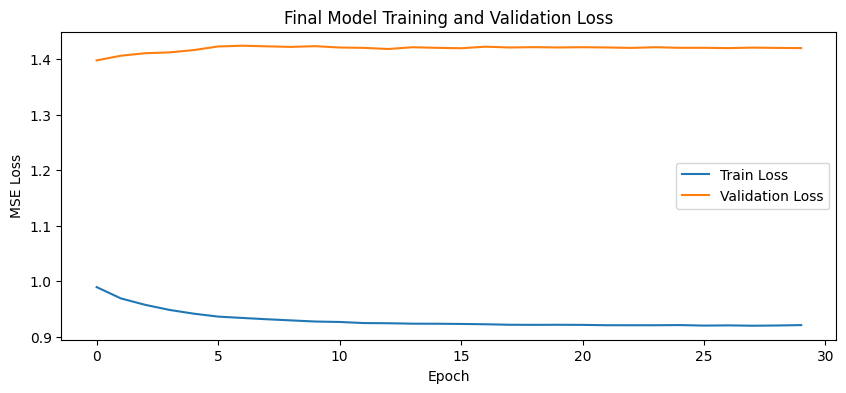

Final Train Loss: 0.9211
Final Val Loss:   1.4201


In [ ]:
# Plot final training curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses_final, label='Train Loss')
plt.plot(val_losses_final,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Final Model Training and Validation Loss')
plt.legend()
plt.show()

print(f"Final Train Loss: {train_losses_final[-1]:.4f}")
print(f"Final Val Loss:   {val_losses_final[-1]:.4f}")

## Training Observations

1) The training loss steadily decreased from ~1.0 to 0.92
showing the model is learning. However the validation
loss increased from 1.38 to 1.42 indicating overfitting.

2) The gap between train and validation loss is expected
for stock return prediction. Daily returns contain
significant random noise. This makes generalisation difficult.

3) The best model was automatically saved and loaded for
generating final predictions.

## Generating Predictions

The trained model predicts the return for 01/04/2022
for all 442 companies.

For each company:
1. Take the last 10 days of scaled returns
2. Feed into the LSTM model
3. Get scaled prediction
4. Inverse transform back to original scale
5. Store prediction


In [ ]:
# Generate predictions for all 442 companies
final_model.eval()
predictions = []

with torch.no_grad(): # no grad -> memory saving -> faster
    for i in range(len(data_scaled)):
        last_sequence = data_scaled[i, -best_params['lookback']:]
        input_seq = torch.FloatTensor(last_sequence).reshape(1, -1, 1).to(device)
        pred_scaled = final_model(input_seq).item()
        pred_original = scaler.mean_[i] + pred_scaled * scaler.scale_[i]
        predictions.append(pred_original)

predictions = np.array(predictions)
print(f"Number of predictions: {len(predictions)}")

# convert to csv file
submission = pd.read_csv('sample_submission.csv')
submission['value'] = predictions
submission.to_csv('submission.csv', index=False)

print(submission.head())

print("\nSubmission file saved!")

Number of predictions: 442
          ID     value
0  company_0  0.013242
1  company_1 -0.105455
2  company_2 -0.002196
3  company_3 -0.010103
4  company_4  0.246070

Submission file saved!


# Moving average baseline
Moving Average is taking the average of recent days to predict tomorrow.

In [ ]:
# Strategy: weighted average of recent days
# More weight on recent days
predictions_ma = []

for i in range(len(data)):
    # Last 30 days with exponentially decreasing weights
    recent = data[i, -30:]
    weights = np.exp(np.linspace(-1, 0, 30))
    weights = weights / weights.sum()
    pred = np.dot(weights, recent)
    predictions_ma.append(pred)

predictions_ma = np.array(predictions_ma)

# Save submission
submission_ma = pd.read_csv('sample_submission.csv')
submission_ma['value'] = predictions_ma
submission_ma.to_csv('submission_ma.csv', index=False)
print("Moving average submission saved!")
print(f"Sample: {predictions_ma[:5]}")


Moving average submission saved!
Sample: [ 0.05885331  0.1431061   0.23027265  0.21457911 -0.53016775]


As an extra approach, I also tried a simple method
that does not use any machine learning.

The idea is simple —> if a stock went up over the
last 30 days, it will probably go up tomorrow too.
I gave more weight to recent days because they are
more relevant than older days.

### Results Comparison
**Optuna LSTM MSE Score ->  2.98**

**Moving Average MSE Score -> 2.78 <- best**


-> Stock returns change randomly every day. The LSTM
model tried to find patterns in this random data
but ended up predicting values very close to zero
for most companies which is not accurate.

-> The moving average just looks at what happened
recently and uses that as the prediction. This
worked better because recent stock movements
are the best indicator of the next day.

-> Stock prices already reflect all available information so it is very hard for any model to find hidden patterns.
Simple approaches therefore often work just as well
or better than complex models.


### The moving average submission (MSE: 2.78) was chosen
as the final Kaggle submission because it gave the
best score.

# Captum

In [ ]:
from captum.attr import IntegratedGradients

final_model.eval()

# select one company to analyse (company_0)
company_idx = 0

# last lookback (10) days for this company
last_sequence = data_scaled[company_idx, -best_params['lookback']:]
input_tensor = torch.FloatTensor(last_sequence).reshape(1, -1, 1).to(device)
input_tensor.requires_grad = True

# Creates a tensor of all zeros
# same shape as input but empty
baseline = torch.zeros_like(input_tensor)

# Gradients object
ig = IntegratedGradients(final_model)

# Calculate attributions
attributions, delta = ig.attribute(
    input_tensor,
    baseline,
    return_convergence_delta=True
)

# Convert to numpy
attr = attributions.squeeze().detach().cpu().numpy()

print("Attributions shape:", attr.shape)
print("Attributions:", attr)
print("Convergence delta:", delta.item())

Attributions shape: (10,)
Attributions: [-4.1196871e-04  1.3003987e-05 -1.9619826e-04  1.0473017e-02
 -8.4073188e-05 -5.2090520e-03 -1.9674643e-03 -6.1622835e-03
 -3.6034880e-03  2.5416121e-03]
Convergence delta: -7.450580596923828e-09


## Captum Output Analysis

The Integrated Gradients analysis produced one
attribution score for each of the 10 input days.

Key findings:

1. **Day-7 had the strongest positive influence**
   (1.0473017e-02 -> 0.0105) meaning what happened 7 days ago pushed the prediction upward the most.

2. **Days -3 and -5 had negative influence** meaning
   they pulled the prediction downward.

3. **Yesterday (Day -1) had a small positive influence**   showing recent data does matter but is not the most important.

4. **The convergence delta is -7.450580596923828e-09** which is essentially zero confirming the attribution calculation is accurate.

Overall the attribution scores are very small
**(around 0.001 to 0.01)** which shows that no
single day dominates the prediction strongly.
This is expected for stock data where finding patterns is very difficult.

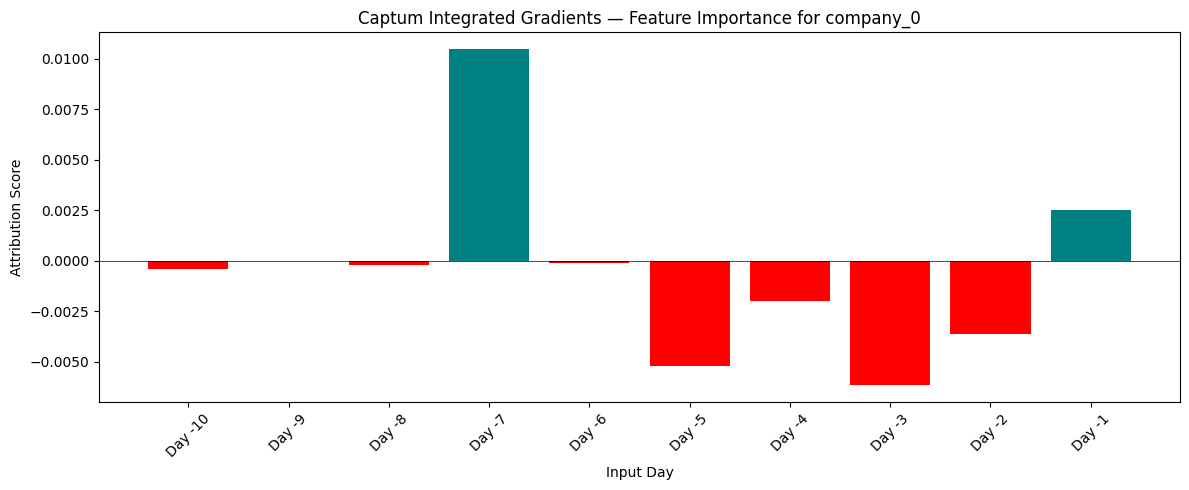


Feature Importance Ranking:
  Rank 1: Day -7 → 0.010473 (positive influence)
  Rank 2: Day -3 → -0.006162 (negative influence)
  Rank 3: Day -5 → -0.005209 (negative influence)
  Rank 4: Day -2 → -0.003603 (negative influence)
  Rank 5: Day -1 → 0.002542 (positive influence)
  Rank 6: Day -4 → -0.001967 (negative influence)
  Rank 7: Day -10 → -0.000412 (negative influence)
  Rank 8: Day -8 → -0.000196 (negative influence)
  Rank 9: Day -6 → -0.000084 (negative influence)
  Rank 10: Day -9 → 0.000013 (positive influence)


In [ ]:
# Day labels
days = [f'Day -{best_params["lookback"]-i}' for i in range(best_params['lookback'])]

# Plot
plt.figure(figsize=(12, 5))
colors = ['red' if x < 0 else 'teal' for x in attr]
plt.bar(days, attr, color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Input Day')
plt.ylabel('Attribution Score')
plt.title(f'Captum Integrated Gradients — Feature Importance for company_0')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
sorted_idx = np.argsort(np.abs(attr))[::-1]
for rank, idx in enumerate(sorted_idx):
    direction = "positive" if attr[idx] > 0 else "negative"
    print(f"  Rank {rank+1}: {days[idx]} → {attr[idx]:.6f} ({direction} influence)")

## Captum Visualisation Analysis

The attribution scores are plotted as a bar chart
to make the results easy to interpret.

1) Teal bars show days that pushed the prediction
upward. Red bars show days that pulled the
prediction downward.

2) The feature importance ranking orders the days
from most to least influential based on the
absolute size of their attribution score.
